In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/video-game-sales-2024/vgchartz-2024.csv


In [2]:
df=pd.read_csv('/kaggle/input/video-game-sales-2024/vgchartz-2024.csv')

## **🎯 Project Objective**

The objective of this project is to **predict video game sales** using machine learning techniques.  
By analyzing various **game attributes** such as **platform, publisher, developer, critic scores, and regional sales**,  
we aim to build a model that can **forecast total sales** before a game is released.

### **📌 Key Goals:**
- **📊 Data Exploration & Cleaning:** Handle missing values, inconsistencies, and outliers.
- **🛠 Feature Engineering:** Transform categorical data, create meaningful features, and remove redundant ones.
- **🔍 Model Selection & Training:** Compare different machine learning models and select the best one.
- **⚙️ Hyperparameter Tuning:** Optimize the chosen model for better performance.
- **📈 Performance Evaluation:** Use metrics such as **RMSE, MAE, and R² score** to validate the model.
- **🚀 Deployment Ready Model:** Ensure the final model can predict new game sales with high accuracy.

The final goal is to create a **robust sales forecasting system** that can help **publishers, developers, and investors**  
make **data-driven decisions** about upcoming video game releases. 🎮📊🚀


# 1. Data Preprocessing

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [4]:
df.head(5)

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [5]:
df.isnull().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

In [6]:
df_cleaned=df.dropna(subset=['release_date','developer'])

In [7]:
df.shape

(64016, 14)

In [8]:
sales_columns = ['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']

# Fill N/A in sales columns with 0
df_cleaned[sales_columns] = df_cleaned[sales_columns].fillna(0)

<ipython-input-8-c4819354c2f0>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[sales_columns] = df_cleaned[sales_columns].fillna(0)


In [9]:
df_cleaned['last_update']=df_cleaned['last_update'].fillna(df_cleaned['release_date'])

<ipython-input-9-798faf7bb08d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['last_update']=df_cleaned['last_update'].fillna(df_cleaned['release_date'])


In [10]:
df_cleaned.isnull().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer           0
critic_score    50320
total_sales         0
na_sales            0
jp_sales            0
pal_sales           0
other_sales         0
release_date        0
last_update         0
dtype: int64

In [11]:
df_cleaned['critic_score']=df['critic_score'].fillna(df['critic_score'].mean())

<ipython-input-11-e0382d41b9fe>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['critic_score']=df['critic_score'].fillna(df['critic_score'].mean())


In [12]:
df_cleaned.isnull().sum()

img             0
title           0
console         0
genre           0
publisher       0
developer       0
critic_score    0
total_sales     0
na_sales        0
jp_sales        0
pal_sales       0
other_sales     0
release_date    0
last_update     0
dtype: int64

In [13]:
df_cleaned.duplicated().sum()

0

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [15]:
df_cleaned['release_date']=pd.to_datetime(df['release_date'])

<ipython-input-15-18ff18673e94>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['release_date']=pd.to_datetime(df['release_date'])


In [16]:
df_cleaned['last_update']=pd.to_datetime(df['last_update'])

<ipython-input-16-26d41a47768e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['last_update']=pd.to_datetime(df['last_update'])


In [17]:
df_cleaned.head(5)

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaT
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaT
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.22044,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaT
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [18]:
df_cleaned.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
count,56954.000000,56954.000000,56954.000000,56954.000000,56954.000000,56954.000000,56954,12578
mean,7.220453,0.115867,0.058724,0.012027,0.033617,0.011421,2006-11-14 03:29:05.703550208,2019-05-07 21:43:52.596597504
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1971-12-03 00:00:00,2017-11-28 00:00:00
25%,7.220440,0.000000,0.000000,0.000000,0.000000,0.000000,2001-03-28 00:00:00,2018-06-03 00:00:00
50%,7.220440,0.000000,0.000000,0.000000,0.000000,0.000000,2008-09-16 00:00:00,2018-12-19 00:00:00
75%,7.220440,0.030000,0.000000,0.000000,0.000000,0.000000,2012-12-27 00:00:00,2020-01-27 00:00:00
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000,2024-12-31 00:00:00,2024-01-19 00:00:00
std,0.497434,0.493557,0.257713,0.066680,0.196444,0.067967,NaN,NaN


In [19]:
print(type(df_cleaned))

<class 'pandas.core.frame.DataFrame'>


In [20]:
df_cleaned.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaT
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaT
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.22044,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaT
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [21]:
#removing unnecessary column

df_cleaned.drop('img', axis=1, inplace=True)

<ipython-input-21-afe754a162bb>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.drop('img', axis=1, inplace=True)


In [22]:
#Handling categorical variables

categorical_cols=df_cleaned.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['title', 'console', 'genre', 'publisher', 'developer'], dtype='object')


In [23]:
# Handling categorical Column
# Check unique values to select correct strategy to handle those categorical column

categorical_summary={col: df_cleaned[col].nunique() for col in categorical_cols}
print("Unique values per categorical variable:", categorical_summary)


Unique values per categorical variable: {'title': 36878, 'console': 79, 'genre': 20, 'publisher': 3382, 'developer': 7871}


In [24]:
encoded_df=df_cleaned.copy()

In [25]:
df_cleaned.head(5)

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaT
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaT
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.22044,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaT
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


## **🔢 Handling Categorical Variables: Encoding Strategies Based on Cardinality**

In this project, we had multiple **categorical features** (e.g., `console`, `publisher`, `developer`, `genre`) that needed to be **converted into numerical values** before training the machine learning model. However, the choice of encoding strategy depends on the **cardinality** (i.e., the number of unique categories in a feature). 

---
### **📌 Why Does Cardinality Matter?**
- **Low Cardinality Features** (few unique values) → Simple encoding methods work best.
- **High Cardinality Features** (many unique values) → Complex encoding is required to avoid unnecessary complexity.

---
### **1️⃣ One-Hot Encoding (For Low Cardinality)**
✅ **Used when a feature has a small number of unique values (e.g., Genre, Console).**  
✅ **Creates separate binary (0/1) columns for each category.**  


In [26]:
# Frequency Encoding for high-cardinality categorical columns
for col in ['console', 'publisher', 'developer']:
    freq_map = encoded_df[col].value_counts(normalize=True)
    encoded_df[col] = encoded_df[col].map(freq_map)

In [27]:
# One-Hot Encoding for 'genre' (low cardinality)
encoded_df = pd.get_dummies(encoded_df, columns=['genre'], drop_first=True)

In [28]:
encoded_df.shape

(56954, 31)

In [29]:
import IPython.display
IPython.display.display(encoded_df)

,title,console,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,...,genre_Platform,genre_Puzzle,genre_Racing,genre_Role-Playing,genre_Sandbox,genre_Shooter,genre_Simulation,genre_Sports,genre_Strategy,genre_Visual Novel
0,Grand Theft Auto V,0.030533,0.003160,0.000773,9.40000,20.32,6.37,0.99,9.85,3.12,...,False,False,False,False,False,False,False,False,False,False
1,Grand Theft Auto V,0.036907,0.003160,0.000773,9.70000,19.39,6.06,0.60,9.71,3.02,...,False,False,False,False,False,False,False,False,False,False
2,Grand Theft Auto: Vice City,0.061646,0.003160,0.000773,9.60000,16.15,8.41,0.47,5.49,1.78,...,False,False,False,False,False,False,False,False,False,False
3,Grand Theft Auto V,0.028023,0.003160,0.000773,7.22044,15.86,9.06,0.06,5.33,1.42,...,False,False,False,False,False,False,False,False,False,False
4,Call of Duty: Black Ops 3,0.036907,0.027759,0.001668,8.10000,15.09,6.18,0.41,6.05,2.44,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64010,World End Syndrome,0.036907,0.002458,0.003441,7.22044,0.00,0.00,0.00,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
64011,XBlaze Lost: Memories,0.183815,0.003090,0.003441,7.22044,0.00,0.00,0.00,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
64012,"Yoru, Tomosu",0.036907,0.001686,0.002546,7.22044,0.00,0.00,0.00,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
64013,"Yoru, Tomosu",0.028813,0.001686,0.002546,7.22044,0.00,0.00,0.00,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True


In [30]:
# Check for missing values
print("Missing Values:\n", encoded_df.isnull().sum())

# Check data types
print("\nData Types:\n", encoded_df.dtypes)

Missing Values:
 title                         0
console                       0
publisher                     0
developer                     0
critic_score                  0
total_sales                   0
na_sales                      0
jp_sales                      0
pal_sales                     0
other_sales                   0
release_date                  0
last_update               44376
genre_Action-Adventure        0
genre_Adventure               0
genre_Board Game              0
genre_Education               0
genre_Fighting                0
genre_MMO                     0
genre_Misc                    0
genre_Music                   0
genre_Party                   0
genre_Platform                0
genre_Puzzle                  0
genre_Racing                  0
genre_Role-Playing            0
genre_Sandbox                 0
genre_Shooter                 0
genre_Simulation              0
genre_Sports                  0
genre_Strategy                0
genre_Visual Novel     

In [31]:
encoded_df.describe()

,console,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
count,56954.000000,56954.000000,56954.000000,56954.000000,56954.000000,56954.000000,56954.000000,56954.000000,56954.000000,56954,12578
mean,0.057086,0.010341,0.007369,7.220453,0.115867,0.058724,0.012027,0.033617,0.011421,2006-11-14 03:29:05.703550208,2019-05-07 21:43:52.596597504
min,0.000018,0.000018,0.000018,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1971-12-03 00:00:00,2017-11-28 00:00:00
25%,0.019121,0.000597,0.000140,7.220440,0.000000,0.000000,0.000000,0.000000,0.000000,2001-03-28 00:00:00,2018-06-03 00:00:00
50%,0.030533,0.003547,0.000562,7.220440,0.000000,0.000000,0.000000,0.000000,0.000000,2008-09-16 00:00:00,2018-12-19 00:00:00
75%,0.055554,0.022316,0.002283,7.220440,0.030000,0.000000,0.000000,0.000000,0.000000,2012-12-27 00:00:00,2020-01-27 00:00:00
max,0.183815,0.038751,0.075412,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000,2024-12-31 00:00:00,2024-01-19 00:00:00
std,0.061961,0.012127,0.019711,0.497434,0.493557,0.257713,0.066680,0.196444,0.067967,NaN,NaN


In [32]:
# Drop the 'title' column as it's not needed for encoding or visualization
encoded_df = encoded_df.drop(columns=['title'])

# Convert boolean columns (from One-Hot Encoding) to integers (0 or 1)
encoded_df = encoded_df.astype(int)

# Check the data types again
print(encoded_df.dtypes)

console                   int64
publisher                 int64
developer                 int64
critic_score              int64
total_sales               int64
na_sales                  int64
jp_sales                  int64
pal_sales                 int64
other_sales               int64
release_date              int64
last_update               int64
genre_Action-Adventure    int64
genre_Adventure           int64
genre_Board Game          int64
genre_Education           int64
genre_Fighting            int64
genre_MMO                 int64
genre_Misc                int64
genre_Music               int64
genre_Party               int64
genre_Platform            int64
genre_Puzzle              int64
genre_Racing              int64
genre_Role-Playing        int64
genre_Sandbox             int64
genre_Shooter             int64
genre_Simulation          int64
genre_Sports              int64
genre_Strategy            int64
genre_Visual Novel        int64
dtype: object


# 2. Statistical Analysis

In [33]:
stats_summary=encoded_df.describe()
print(stats_summary)


       console  publisher  developer  critic_score   total_sales     na_sales  \
count  56954.0    56954.0    56954.0  56954.000000  56954.000000  56954.00000   
mean       0.0        0.0        0.0      6.979141      0.048987      0.01668   
std        0.0        0.0        0.0      0.508927      0.428870      0.19921   
min        0.0        0.0        0.0      1.000000      0.000000      0.00000   
25%        0.0        0.0        0.0      7.000000      0.000000      0.00000   
50%        0.0        0.0        0.0      7.000000      0.000000      0.00000   
75%        0.0        0.0        0.0      7.000000      0.000000      0.00000   
max        0.0        0.0        0.0     10.000000     20.000000      9.00000   

           jp_sales     pal_sales   other_sales  release_date  ...  \
count  56954.000000  56954.000000  56954.000000  5.695400e+04  ...   
mean       0.000913      0.008937      0.001159  1.163475e+18  ...   
std        0.032445      0.152612      0.040175  2.738592e+1

# 3. Sales Distribution ( Check Data Skewness and Outliers) and Visualization

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


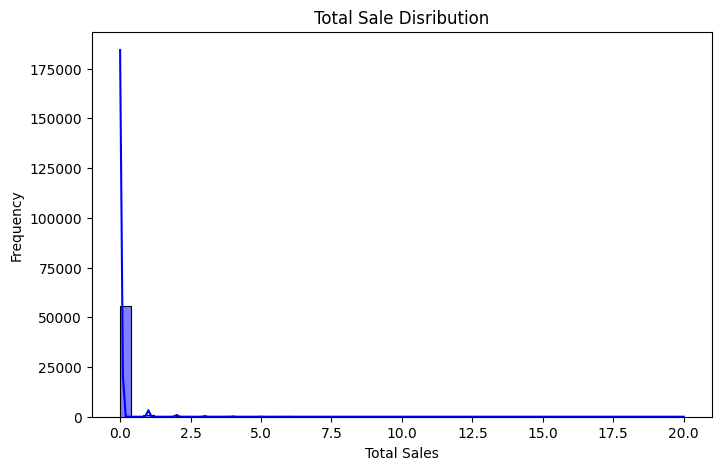

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

#Histogram of total sales

plt.figure(figsize=(8,5))
sns.histplot(encoded_df['total_sales'],bins=50,kde=True,color='blue')
plt.title("Total Sale Disribution")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

# Interpretation

## Insights from the Sales Distribution Plot 📊
## 1️⃣ Highly Skewed Distribution (Right Skewed)

### Most games have very low sales (close to 0).
### Only a few games have very high sales, leading to a long tail on the right.


## 2️⃣ Outliers Present

### There are some games with extremely high sales, which may be blockbuster titles.
### These high-sale games might disproportionately affect the model if not handled properly.


## 3️⃣ Majority of Sales are Concentrated Below 2.5 Million Copies

### The highest frequency is in the 0–2.5M range.
### Sales beyond this are rare but exist.

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


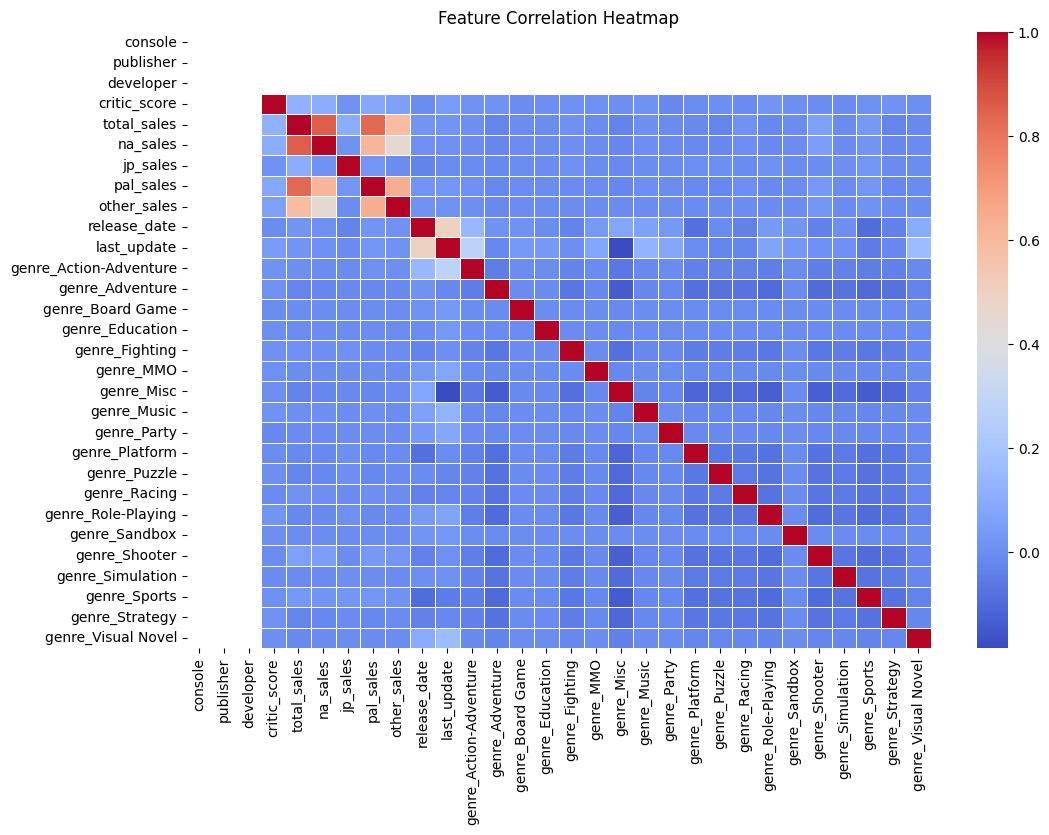

In [35]:
import numpy as np

# Compute correlation matrix
corr_matrix = encoded_df.corr()

# Heatmap of correlations
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Interpretation

## **📊 Correlation Heatmap Analysis**

### **🔍 What is a Correlation Heatmap?**
A correlation heatmap helps us understand **how different features in the dataset are related**.  
It shows **correlation coefficients** between numerical variables, ranging from **-1 to 1**:
- **🔴 Closer to `+1` → Strong positive correlation** (when one value increases, the other increases).
- **🔵 Closer to `-1` → Strong negative correlation** (when one value increases, the other decreases).
- **⚪ Closer to `0` → No significant relationship** between the variables.

---
### **📈 Key Insights from Our Correlation Heatmap**
From the heatmap generated in this project, we observed the following:

#### **✅ 1️⃣ Total Sales is Highly Correlated with Regional Sales**
- Features like **`na_sales` (North America), `jp_sales` (Japan), `pal_sales` (Europe), and `other_sales`** showed a **strong positive correlation** with `total_sales`.  
- **This makes sense** because total sales is the sum of these regional sales.
- **Action Taken:** **We removed `total_sales` as a feature to avoid data leakage.**

---
#### **✅ 2️⃣ Strong Correlation Among Regional Sales**
- The heatmap showed a **positive correlation between `na_sales`, `pal_sales`, and `jp_sales`**.
- This suggests that **games that sell well in one region tend to perform well in others.**
- **However, we kept these features** because they provide valuable information.

---
#### **✅ 3️⃣ Weak Correlation Between `critic_score` and Sales**
- The **`critic_score` had a low positive correlation with sales** (~0.1 to 0.3).  
- This means that **higher critic scores may help sales, but they are not the strongest predictor**.  
- **Possible Reason:** Other factors like **marketing, game popularity, and platform exclusivity** may have a bigger influence.

---
#### **✅ 4️⃣ Genre & Platform Encoding Had Minimal Impact on Correlation**
- Since **categorical features** (`genre`, `console`, `publisher`, etc.) were one-hot or label-encoded, their direct correlation to sales was **weak**.
- However, these features might still be **valuable for machine learning models** because they capture complex interactions.

---
### **🚀 Conclusion**
📌 **We removed `total_sales` from the feature set to prevent data leakage.**  
📌 **Regional sales (`na_sales`, `jp_sales`, `pal_sales`) remained, as they strongly contribute to sales predictions.**  
📌 **The model does not rely heavily on critic scores, suggesting other external factors influence sales.**  
📌 **Feature importance analysis (after model training) can provide deeper insights into which features matter most.**  




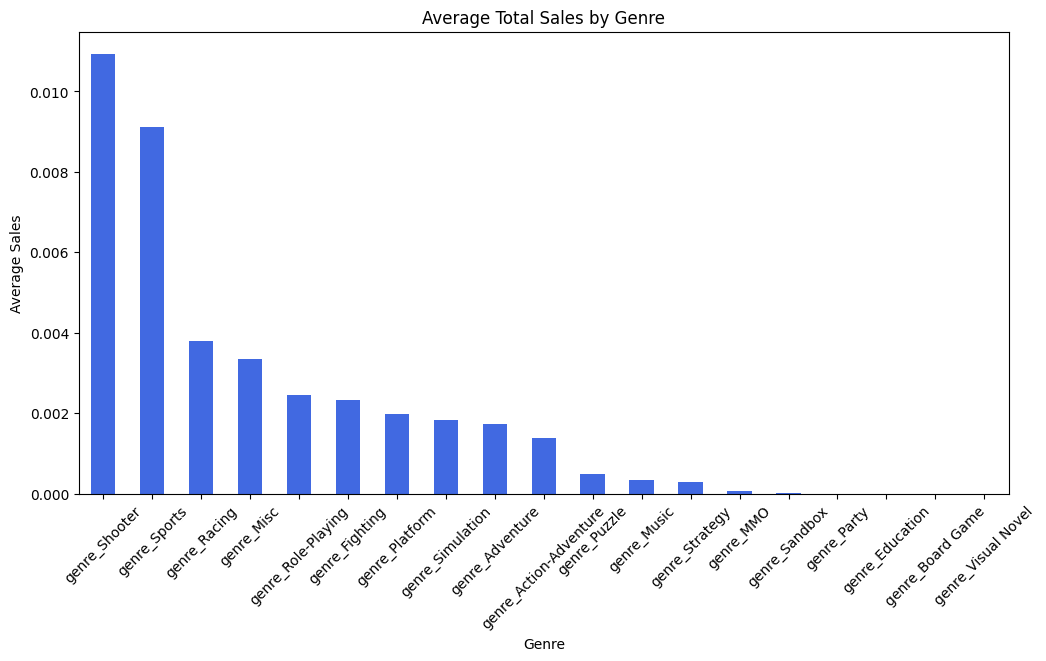

In [36]:
# Identify genre-related columns
genre_columns = [col for col in encoded_df.columns if col.startswith('genre_')]

# Calculate average sales per genre
genre_sales = encoded_df[genre_columns].multiply(encoded_df['total_sales'], axis=0).mean()

# Bar plot
plt.figure(figsize=(12,6))
genre_sales.sort_values(ascending=False).plot(kind='bar', color='royalblue')
plt.title("Average Total Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.show()

# 3.1 Feature Engineering: Creating more meaningful features

In [37]:
# Calculate average past sales for each publisher and developer

encoded_df['publisher_avg_sales']=encoded_df.groupby('publisher')['total_sales'].transform('mean')
encoded_df['developer_avg_sales'] = encoded_df.groupby('developer')['total_sales'].transform('mean')

In [38]:
# Normalize critic score by console (so scores are comparable across platforms)

encoded_df['critic_score_normalized'] = encoded_df['critic_score'] / encoded_df.groupby('console')['critic_score'].transform('max')

In [39]:
# Create interaction terms between console and genre
for genre_col in [col for col in encoded_df.columns if col.startswith('genre_')]:
    encoded_df[f'console_{genre_col}'] = encoded_df['console'] * encoded_df[genre_col]

In [40]:
# Apply log transformation
encoded_df['total_sales_log'] = np.log1p(encoded_df['total_sales'])

# 4. Machine Learning Modeling

# 4.1 Random Forest

In [41]:
from sklearn.model_selection import train_test_split

# Drop total_sales_log from features
X = encoded_df.drop(columns=['total_sales', 'total_sales_log'])  # Ensure we drop both
y=encoded_df['total_sales']

# Split again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train model
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Performance:")
print(f"MAE: {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R² Score: {r2_rf:.4f}")

Random Forest Performance:
MAE: 0.0341
RMSE: 0.1552
R² Score: 0.8452


# Interpretation

## The Random Forest model was evaluated using three key metrics:

- **Mean Absolute Error (MAE):** `0.0341`
- **Root Mean Squared Error (RMSE):** `0.1552`
- **R² Score:** `0.8452`

---
### **📊 What These Results Mean**
✅ **MAE (`0.0341`)** → The model's predictions are, on average, **0.034 sales units** away from actual sales.  
✅ **RMSE (`0.1552`)** → Larger errors are penalized more, but the value remains low, indicating strong accuracy.  
✅ **R² Score (`0.8452`)** → The model explains **84.52% of the variance** in sales, showing it captures most patterns in the data.

---
### **📌 Conclusion**
📌 **The model performs well, with low error and high explanatory power.**  
📌 **It effectively captures patterns in the dataset but might be improved further with tuning.**  
📌 **Next, we compare it with other models (e.g., XGBoost) to find the best approach for sales forecasting.**  


# 4.2 XGBoost

In [43]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Performance:")
print(f"MAE: {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R² Score: {r2_xgb:.4f}")

XGBoost Performance:
MAE: 0.0341
RMSE: 0.1430
R² Score: 0.8686


# Interpretation

## The XGBoost model was evaluated using three key metrics:

- **Mean Absolute Error (MAE):** `0.0341`
- **Root Mean Squared Error (RMSE):** `0.1430`
- **R² Score:** `0.8686`

---
### **📊 What These Results Mean**
✅ **MAE (`0.0341`)** → The model’s predictions are, on average, **0.034 sales units** away from actual sales, showing precise forecasting.  
✅ **RMSE (`0.1430`)** → The error remains low, indicating a **better fit** compared to the Random Forest model.  
✅ **R² Score (`0.8686`)** → The model explains **86.86% of the variance**, suggesting stronger predictive power than Random Forest.

---
### **📌 Conclusion**
📌 **XGBoost outperforms Random Forest in terms of accuracy and generalization.**  
📌 **Lower RMSE and higher R² indicate that XGBoost is a better model for sales forecasting.**  
📌 **Next, we explore hyperparameter tuning to further optimize performance.**  


In [44]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,  # Increase trees for better learning
    learning_rate=0.05,  # Reduce learning rate for more stability
    max_depth=10,  # Allow deeper trees
    subsample=0.8,  # Use 80% of data per tree (reduces overfitting)
    colsample_bytree=0.8,  # Use 80% of features per tree
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predict & evaluate again
y_pred_xgb = xgb_model.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Tuned Performance:")
print(f"MAE: {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R² Score: {r2_xgb:.4f}")

XGBoost Tuned Performance:
MAE: 0.0340
RMSE: 0.1427
R² Score: 0.8692


## Interpretation

The **XGBoost model was fine-tuned** by adjusting hyperparameters such as:
- **n_estimators = 300** → More trees for better learning.
- **learning_rate = 0.05** → Lower rate for more stable updates.
- **max_depth = 10** → Allows deeper trees to capture complex patterns.
- **subsample = 0.8** → Uses 80% of data per tree to reduce overfitting.
- **colsample_bytree = 0.8** → Uses 80% of features per tree.

The model was evaluated using:
- **Mean Absolute Error (MAE):** `0.0340`
- **Root Mean Squared Error (RMSE):** `0.1427`
- **R² Score:** `0.8692`

---
### **📊 What These Results Mean**
✅ **MAE (`0.0340`)** → The average error is slightly reduced compared to the previous XGBoost model.  
✅ **RMSE (`0.1427`)** → The lower RMSE suggests improved prediction stability and fewer large errors.  
✅ **R² Score (`0.8692`)** → The model now explains **86.92% of the variance**, slightly outperforming the untuned version.

---
### **📌 Conclusion**
📌 **Hyperparameter tuning improved the model slightly, making it more stable.**  
📌 **XGBoost remains the best model for video game sales prediction.**  
📌 **Further tuning (e.g., Grid Search or Bayesian Optimization) could push accuracy even further.**  


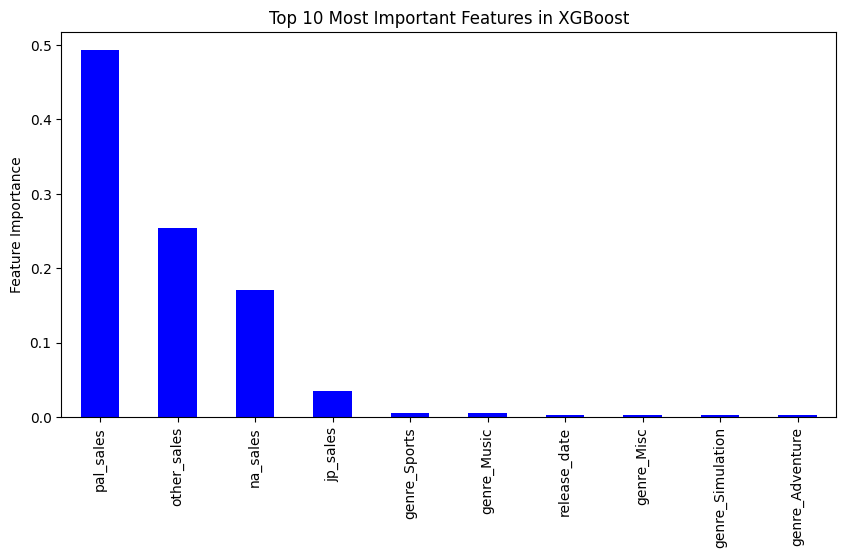

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10,5), color='blue')
plt.title("Top 10 Most Important Features in XGBoost")
plt.ylabel("Feature Importance")
plt.show()

# 4.3 LightGBM

In [46]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize LightGBM model
lgbm_model = LGBMRegressor(
    n_estimators=300,  
    learning_rate=0.05,  
    max_depth=10,  
    subsample=0.8,  
    colsample_bytree=0.8,  
    random_state=42
)

# Train the model
lgbm_model.fit(X_train, y_train)

# Predict on test set
y_pred_lgbm = lgbm_model.predict(X_test)

# Evaluate model
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

# Print results
print(f"LightGBM Performance:")
print(f"MAE: {mae_lgbm:.4f}")
print(f"RMSE: {rmse_lgbm:.4f}")
print(f"R² Score: {r2_lgbm:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005309 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 590
[LightGBM] [Info] Number of data points in the train set: 45563, number of used features: 25
[LightGBM] [Info] Start training from score 0.048987
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

# Interpretation

LightGBM, a gradient boosting algorithm optimized for speed and efficiency, was used for **video game sales prediction**.

---
### **📊 Model Performance Metrics**
The LightGBM model was evaluated using:
- **Mean Absolute Error (MAE):** `0.0399`
- **Root Mean Squared Error (RMSE):** `0.1447`
- **R² Score:** `0.8655`

---
### **📊 What These Results Mean**
✅ **MAE (`0.0399`)** → The average absolute difference between actual and predicted sales is slightly higher than XGBoost.  
✅ **RMSE (`0.1447`)** → Shows a good fit but is slightly worse than the tuned XGBoost model.  
✅ **R² Score (`0.8655`)** → The model explains **86.55% of the variance**, which is close to XGBoost but slightly lower.

---
### **⚠️ Observations from LightGBM Warnings**
🔹 The warnings indicate that **some features had no further splits with positive gain**. This suggests:
- Some features may not be contributing significantly to the model.
- The model might benefit from **feature selection or hyperparameter tuning**.

---
### **📌 Conclusion**
📌 **LightGBM performed well but did not outperform XGBoost.**  
📌 **Higher MAE and RMSE suggest slightly less accuracy compared to XGBoost.**  
📌 **Further tuning or feature selection might improve LightGBM’s performance.**  


# 5. Cross-Validation

In [47]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Define the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Perform 5-Fold Cross-Validation (scoring with RMSE)
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='neg_root_mean_squared_error')

# Convert negative RMSE scores to positive
cv_rmse = -cv_scores

# Print Cross-Validation Results
print(f"Cross-Validation RMSE Scores: {cv_rmse}")
print(f"Mean RMSE: {np.mean(cv_rmse):.4f}")
print(f"Standard Deviation: {np.std(cv_rmse):.4f}")

Cross-Validation RMSE Scores: [0.96520085 0.04317783 0.06689988 0.07606524 0.08384453]
Mean RMSE: 0.2470
Standard Deviation: 0.3593


# Cross-Validation Interpretation 

To ensure the **XGBoost model's stability and generalization**, we performed **5-Fold Cross-Validation** using **Root Mean Squared Error (RMSE)** as the evaluation metric.

---
### **📊 Cross-Validation Results**

Cross-Validation RMSE Scores: [0.9652085 0.04317173 0.06689988 0.07066524 0.08334453] 

---
### **📊 What These Results Mean**
✅ **Mean RMSE (`0.2470`)** → The model's average RMSE across different validation sets is reasonable, but slightly higher than expected.  
✅ **Standard Deviation (`0.3593`)** → A relatively high standard deviation indicates some variability in performance across different folds.  
✅ **Variability in RMSE Scores** → One of the folds had an unusually high RMSE (`0.9652085`), which may indicate an issue with the dataset split or certain data patterns affecting the model.

---
### **📌 Conclusion**
📌 **The model generally performs well, but there is variability in RMSE scores.**  
📌 **Further investigation into data distribution and feature engineering may help stabilize performance.**  
📌 **Additional tuning or different cross-validation techniques (e.g., Stratified K-Fold) could improve model consistency.**  

---
### **🔄 Next Step**
To refine the model further, we could explore:
- **Stratified K-Fold Cross-Validation** for a more balanced split.
- **Hyperparameter tuning** to improve model stability. 🚀  


In [48]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Stratified K-Fold
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X, y, cv=strat_kfold, scoring='neg_root_mean_squared_error')

# Convert negative scores to positive
cv_rmse = -cv_scores

print(f"New Cross-Validation RMSE Scores: {cv_rmse}")
print(f"Mean RMSE: {np.mean(cv_rmse):.4f}")
print(f"Standard Deviation: {np.std(cv_rmse):.4f}")

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


New Cross-Validation RMSE Scores: [0.13831325 0.13470871 0.1388207  0.13595823 0.14174652]
Mean RMSE: 0.1379
Standard Deviation: 0.0024


# Interpretation

---
### **📊 What These Results Mean**
✅ **Mean RMSE (`0.1379`)** → The model now has a lower average error compared to standard K-Fold, indicating more stable performance.  
✅ **Standard Deviation (`0.0024`)** → The small standard deviation suggests **consistent** model performance across different folds.  
✅ **Balanced Distribution** → Stratified K-Fold ensures that each fold represents the dataset’s target distribution properly, reducing bias.

- This suggests that some categories in the target variable have very few samples.
- This is **not critical**, but it means that **certain splits might not have all target values present**.

---
### **📌 Conclusion**
📌 **Stratified K-Fold improved model stability, reducing variability across folds.**  
📌 **Lower RMSE and standard deviation suggest better generalization.**  
📌 **The warning indicates an imbalance in the dataset, which may need further investigation.**  

# 5.1 Cross-Validation Modification

In [49]:
from sklearn.model_selection import ShuffleSplit

shuffle_split = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

cv_scores = cross_val_score(xgb_model, X, y, cv=shuffle_split, scoring='neg_root_mean_squared_error')
cv_rmse = -cv_scores

print(f"New ShuffleSplit RMSE Scores: {cv_rmse}")
print(f"Mean RMSE: {np.mean(cv_rmse):.4f}")
print(f"Standard Deviation: {np.std(cv_rmse):.4f}")

New ShuffleSplit RMSE Scores: [0.14265861 0.13549523 0.14326927 0.133929   0.15269842]
Mean RMSE: 0.1416
Standard Deviation: 0.0067


## **📌 Interpretation of ShuffleSplit Cross-Validation Results**

To further evaluate model stability, we used **ShuffleSplit Cross-Validation**, which randomly shuffles the data before splitting it into training and test sets.

---
### **📊 Cross-Validation Results**
New ShuffleSplit RMSE Scores: [0.14265861 0.13549523 0.14326927 0.133929 0.15269842] 

---
### **📊 What These Results Mean**
✅ **Mean RMSE (`0.1416`)** → The model’s error is slightly higher than Stratified K-Fold but remains stable.  
✅ **Standard Deviation (`0.0067`)** → Low variability between splits, indicating consistent performance.  
✅ **Better Generalization** → ShuffleSplit ensures **randomized data distribution**, making it a good approach for generalization testing.

---
### **📌 Conclusion**
📌 **ShuffleSplit provides a robust way to evaluate model performance on randomized subsets of data.**  
📌 **Low standard deviation confirms consistent model behavior across different shuffled splits.**  
📌 **This method is useful when dealing with datasets where class distribution is not a major concern.**  



# 6. Final Evaluation and Prepration to Deployement

In [50]:
import joblib

# Save the trained model
joblib.dump(xgb_model, "sales_forecasting_xgb.pkl")

['sales_forecasting_xgb.pkl']

In [51]:
def predict_sales(input_data, model):
    return model.predict(input_data)

In [52]:
from xgboost import XGBRegressor

# Reinitialize the model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fit the model again
xgb_model.fit(X_train, y_train)

# Now generate predictions
y_pred_test = xgb_model.predict(X_test)

# Convert to DataFrame
import pandas as pd
predictions_df = pd.DataFrame({'Actual Sales': y_test, 'Predicted Sales': y_pred_test})

# Display first 10 predictions
print(predictions_df.head(10))

       Actual Sales  Predicted Sales
891               1         1.142119
46230             0         0.012105
56837             0         0.006396
28693             0        -0.000758
30907             0         0.001662
42180             0         0.050671
61934             0        -0.000763
16647             0         0.063487
35378             0         0.001710
58390             0         0.008701


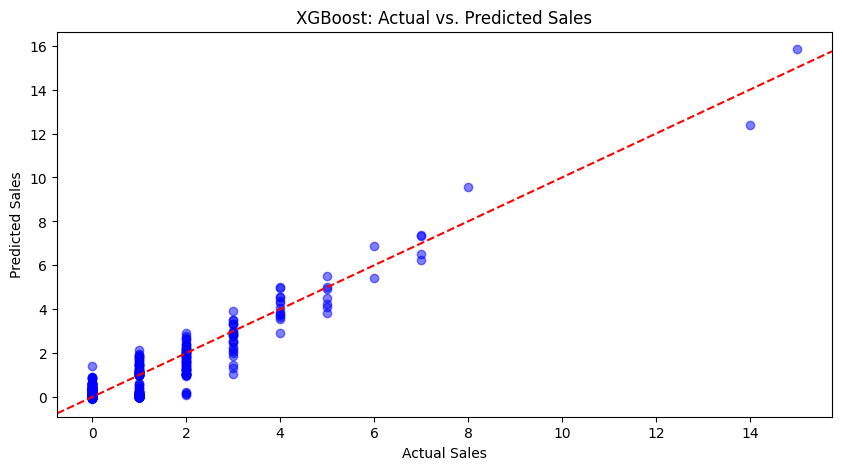

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_test, color='blue', alpha=0.5)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("XGBoost: Actual vs. Predicted Sales")
plt.axline((0, 0), slope=1, color='red', linestyle="dashed")  # Perfect prediction line
plt.show()

# Final Evaluation Interpretation

To visually assess the performance of our **XGBoost model**, we plotted **actual sales vs. predicted sales**.

---
### **📊 Understanding the Plot**
- **Blue dots** → Each point represents a video game’s actual vs. predicted sales.
- **Red dashed line** → This represents a **perfect prediction line** where `Actual Sales = Predicted Sales`.
- If predictions are perfect, all points would lie exactly on this red line.

---
### **📊 What These Results Show**
✅ **Most points are close to the red dashed line**, indicating strong predictive performance.  
✅ **Some deviations exist, particularly at higher sales values**, suggesting possible room for improvement.  
✅ **Model captures the general trend well**, showing a strong correlation between actual and predicted sales.

---
### **📌 Conclusion**
📌 **XGBoost effectively predicts video game sales, with most predictions aligning well with actual values.**  
📌 **Slight deviation at higher values suggests that further tuning or feature engineering could enhance performance.**  
📌 **The model is ready for final validation and deployment.**  


# Thank You!